# Embeddings Multimodales con Google Gemini Embedding 2
---

### ¿Qué son los embeddings multimodales?

Un **embedding** es una representación numérica de un dato (texto, imagen, audio, video) como un vector de números reales en un espacio de alta dimensión. Los embeddings capturan el **significado semántico**: datos con significados similares quedan cerca en ese espacio vectorial.

Los **embeddings multimodales** llevan esto más lejos: mapean **diferentes tipos de datos** (texto, imágenes, audio, video) al **mismo espacio vectorial**. Esto permite comparar directamente, por ejemplo, una imagen con una descripción de texto.

### Google Gemini Embedding 2

[`gemini-embedding-2`](https://ai.google.dev/gemini-api/docs/embeddings) es el **primer modelo de embeddings nativo multimodal** de Google, construido sobre la arquitectura Gemini. Sus características principales son:

| Característica | Detalle |
|---|---|
| Modalidades | Texto, imágenes (PNG/JPEG), video (MP4/MOV), audio, documentos PDF |
| Dimensión del vector | 3072 (por defecto), ajustable con MRL |
| Tokens máximos | 8192 tokens de entrada |
| Imágenes por request | Hasta 6 imágenes |
| Video | Hasta 120 segundos |
| Audio | Hasta 180 segundos |
| Idiomas | +100 idiomas |
| Espacio semántico | **Unificado** — todos los tipos de dato comparten el mismo espacio |

---

### Contenido de este Notebook

1. **Instalación y configuración**
2. **Conceptos fundamentales** — ¿Qué es un vector de embedding?
3. **Embeddings de texto** — Uso básico
4. **Task prefixes** — Optimizar embeddings para cada tarea
5. **Embeddings de imágenes** — Embed de imágenes con datos en memoria
6. **Embeddings multimodales** — Texto + imagen en un solo vector
7. **Búsqueda cross-modal** — Buscar imágenes con consultas de texto
8. **Reducción de dimensionalidad (MRL)** — Ajustar el tamaño del vector
9. **Visualización con PCA/t-SNE** — Ver el espacio de embeddings
10. **Caso de uso: RAG Multimodal** — Mini-sistema de recuperación

---
## 1. Instalación y Configuración

In [ ]:
# Instalar el SDK de Google GenAI
!pip install -q google-genai Pillow matplotlib scikit-learn requests numpy python-dotenv

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import requests
from io import BytesIO
import base64

# SDK de Google
from google import genai
from google.genai import types

# Para análisis
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


In [ ]:
# ─── CONFIGURACIÓN DE API KEY ───────────────────────────────────────────────
# Opción 1: variable de entorno (recomendado para producción)
#   export GEMINI_API_KEY="tu_api_key_aqui"
#
# Opción 2: Google Colab Secrets (recomendado en Colab)
#   from google.colab import userdata
#   os.environ["GEMINI_API_KEY"] = userdata.get('GEMINI_API_KEY')
#
# Opción 3: Directamente (solo para pruebas locales, NO subir a repositorios)
#   os.environ["GEMINI_API_KEY"] = "tu_api_key_aqui"

from dotenv import load_dotenv
load_dotenv()

True

In [ ]:
# Verificar que se cargaron (sin imprimir los valores reales)
variables = ["GOOGLE_API_KEY", "GOOGLE_CLOUD_PROJECT", "GOOGLE_CLOUD_PROJECT_NUMBER"]
for var in variables:
    valor = os.getenv(var)
    estado = "✅ cargada" if valor else "❌ no encontrada"
    print(f"  {var}: {estado}")

# El cliente toma la API key automáticamente de la variable de entorno GEMINI_API_KEY
client = genai.Client()

# Si necesitas el project explícitamente:
PROJECT_ID     = os.getenv("GOOGLE_CLOUD_PROJECT")
PROJECT_NUMBER = os.getenv("GOOGLE_CLOUD_PROJECT_NUMBER")

MODEL = "gemini-embedding-2"  # Modelo GA (General Availability)
# Alternativa preview con más features en beta:
# MODEL = "gemini-embedding-2-preview"

print(f"✅ Cliente configurado. Modelo: {MODEL}")

  GOOGLE_API_KEY: ✅ cargada
  GOOGLE_CLOUD_PROJECT: ✅ cargada
  GOOGLE_CLOUD_PROJECT_NUMBER: ✅ cargada
✅ Cliente configurado. Modelo: gemini-embedding-2


---
## 2. Conceptos Fundamentales

Antes de usar la API, entendamos qué produce un embedding.

In [ ]:
# ── Generar el primer embedding ──────────────────────────────────────────────
resultado = client.models.embed_content(
    model=MODEL,
    contents="Inteligencia Artificial"
)

vector = resultado.embeddings[0].values

print(f"Tipo de dato: {type(vector)}")
print(f"Número de dimensiones: {len(vector)}")
print(f"Primeras 10 dimensiones: {vector[:10]}")
print(f"\nEl vector tiene {len(vector)} números que representan el significado semántico del texto.")

Tipo de dato: <class 'list'>
Número de dimensiones: 3072
Primeras 10 dimensiones: [-0.018368324, -0.009217849, -0.016852202, 0.005483757, 0.02420563, 0.019238776, 0.0051174085, 0.006418966, -0.0039755325, -0.03622164]

El vector tiene 3072 números que representan el significado semántico del texto.


In [ ]:
# ── Similitud coseno: la métrica de distancia fundamental ───────────────────
# cos(θ) = (A · B) / (||A|| * ||B||)
# Rango: [-1, 1] donde 1 = idéntico, 0 = ortogonal, -1 = opuesto

def get_embedding(text):
    """Obtiene el vector de embedding para un texto."""
    res = client.models.embed_content(model=MODEL, contents=text)
    return np.array(res.embeddings[0].values)

def cosine_sim(v1, v2):
    """Calcula la similitud coseno entre dos vectores."""
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

# Comparar pares de frases
pares = [
    ("El gato duerme en el sofá",  "El felino descansa en el mueble"),  # Sinónimos
    ("El gato duerme en el sofá",  "El perro juega en el jardín"),       # Misma estructura, diferente
    ("El gato duerme en el sofá",  "La bolsa de valores cayó un 3%"),    # Temas totalmente diferentes
    ("Machine Learning",            "Aprendizaje Automático"),           # Bilingüe: mismo concepto
]

print("Similitud Coseno entre pares de frases")
print("=" * 70)
for frase_a, frase_b in pares:
    emb_a = get_embedding(frase_a)
    emb_b = get_embedding(frase_b)
    sim = cosine_sim(emb_a, emb_b)
    barra = "█" * int(sim * 20) if sim > 0 else ""
    print(f"\n  A: '{frase_a}'")
    print(f"  B: '{frase_b}'")
    print(f"  Similitud: {sim:.4f}  {barra}")

Similitud Coseno entre pares de frases

  A: 'El gato duerme en el sofá'
  B: 'El felino descansa en el mueble'
  Similitud: 0.7744  ███████████████

  A: 'El gato duerme en el sofá'
  B: 'El perro juega en el jardín'
  Similitud: 0.5456  ██████████

  A: 'El gato duerme en el sofá'
  B: 'La bolsa de valores cayó un 3%'
  Similitud: 0.4613  █████████

  A: 'Machine Learning'
  B: 'Aprendizaje Automático'
  Similitud: 0.8128  ████████████████


---
## 3. Task Prefixes: Optimizar Embeddings para Cada Tarea

Gemini Embedding 2 acepta **instrucciones de tarea** en el prompt para orientar la representación vectorial. Esto mejora significativamente el rendimiento en tareas específicas.

In [ ]:
# ── Prefijos de tarea recomendados ────────────────────────────────────────────
# Formato para CONSULTAS (query):
#   "task: <tarea> | query: <contenido>"
#
# Formato para DOCUMENTOS (corpus a recuperar):
#   "title: <título> | text: <contenido>"

# Base de conocimiento de ejemplo
documentos = [
    {
        "titulo": "Redes Neuronales Convolucionales",
        "texto": "Las CNN son especialmente efectivas para el análisis de imágenes. Usan filtros convolucionales para extraer características locales como bordes, texturas y formas."
    },
    {
        "titulo": "Transformers y Atención",
        "texto": "El mecanismo de atención permite al modelo enfocarse en partes relevantes del input. BERT y GPT son ejemplos de modelos basados en Transformers para NLP."
    },
    {
        "titulo": "Regularización en Redes Neuronales",
        "texto": "El dropout y la normalización por lotes son técnicas para prevenir el sobreajuste. El dropout desactiva neuronas aleatoriamente durante el entrenamiento."
    },
    {
        "titulo": "Algoritmos de Clustering",
        "texto": "K-means divide los datos en K grupos. DBSCAN encuentra clusters de forma arbitraria basándose en densidad. Son útiles para segmentación de clientes."
    },
]

# Generar embeddings para los documentos
def embed_documento(titulo, texto):
    prompt = f"title: {titulo} | text: {texto}"
    res = client.models.embed_content(model=MODEL, contents=prompt)
    return np.array(res.embeddings[0].values)

def embed_query_busqueda(query):
    prompt = f"task: search result | query: {query}"
    res = client.models.embed_content(model=MODEL, contents=prompt)
    return np.array(res.embeddings[0].values)

# Indexar documentos
print("Indexando documentos...")
embeddings_docs = []
for doc in documentos:
    emb = embed_documento(doc["titulo"], doc["texto"])
    embeddings_docs.append(emb)
    print(f"  ✓ '{doc['titulo']}'")

print("\n✅ Base de conocimiento indexada.")

Indexando documentos...
  ✓ 'Redes Neuronales Convolucionales'
  ✓ 'Transformers y Atención'
  ✓ 'Regularización en Redes Neuronales'
  ✓ 'Algoritmos de Clustering'

✅ Base de conocimiento indexada.


In [ ]:
# ── Búsqueda semántica ────────────────────────────────────────────────────────
def buscar(query, top_k=2):
    emb_query = embed_query_busqueda(query)
    similitudes = [
        cosine_sim(emb_query, emb_doc)
        for emb_doc in embeddings_docs
    ]
    indices_ordenados = np.argsort(similitudes)[::-1][:top_k]

    print(f"\n🔍 Consulta: '{query}'")
    print("-" * 60)
    for i, idx in enumerate(indices_ordenados):
        doc = documentos[idx]
        print(f"  #{i+1} [{similitudes[idx]:.4f}] {doc['titulo']}")
        print(f"       {doc['texto'][:80]}...")

# Probar consultas
buscar("¿Cómo funciona la visión por computadora?")
buscar("técnicas para evitar el overfitting")
buscar("¿Qué es la segmentación de clientes?")


🔍 Consulta: '¿Cómo funciona la visión por computadora?'
------------------------------------------------------------
  #1 [0.6217] Redes Neuronales Convolucionales
       Las CNN son especialmente efectivas para el análisis de imágenes. Usan filtros c...
  #2 [0.5971] Transformers y Atención
       El mecanismo de atención permite al modelo enfocarse en partes relevantes del in...

🔍 Consulta: 'técnicas para evitar el overfitting'
------------------------------------------------------------
  #1 [0.7647] Regularización en Redes Neuronales
       El dropout y la normalización por lotes son técnicas para prevenir el sobreajust...
  #2 [0.6205] Transformers y Atención
       El mecanismo de atención permite al modelo enfocarse en partes relevantes del in...

🔍 Consulta: '¿Qué es la segmentación de clientes?'
------------------------------------------------------------
  #1 [0.7216] Algoritmos de Clustering
       K-means divide los datos en K grupos. DBSCAN encuentra clusters de forma ar

---
## 4. Embeddings de Imágenes

Gemini Embedding 2 puede procesar imágenes directamente. Las imágenes se envían como **bytes base64** con su tipo MIME.

In [ ]:
# ── Función helper para cargar imágenes desde URLs ───────────────────────────
def cargar_imagen_url(url):
    """Descarga una imagen verificando que el contenido sea válido."""
    respuesta = requests.get(url, headers=HEADERS, timeout=15)
    respuesta.raise_for_status()

    # Verificar que el Content-Type sea imagen
    content_type = respuesta.headers.get("Content-Type", "")
    if "image" not in content_type:
        raise ValueError(f"URL no devolvió imagen. Content-Type: {content_type}")

    # Verificar que PIL pueda abrirla antes de retornar
    img_bytes = respuesta.content
    Image.open(BytesIO(img_bytes)).verify()  # lanza excepción si está corrupta
    return img_bytes

# URLs alternativas más estables
urls_imagenes = {
    "perro":  "https://picsum.photos/seed/labrador/320/240",
    "gato":   "https://upload.wikimedia.org/wikipedia/commons/thumb/3/3a/Cat03.jpg/640px-Cat03.jpg",
    "auto":   "https://picsum.photos/seed/toyota/320/240",
    "flores": "https://picsum.photos/seed/sunflower/320/240",
}

# Headers para evitar bloqueos por User-Agent
HEADERS = {
    "User-Agent": "Mozilla/5.0 (compatible; NLP-Course-Notebook/1.0)"
}


# Descargar con reporte de estado
print("Descargando imágenes de ejemplo...")
imagenes_bytes = {}
for nombre, url in urls_imagenes.items():
    try:
        imagenes_bytes[nombre] = cargar_imagen_url(url)
        img = Image.open(BytesIO(imagenes_bytes[nombre]))
        print(f"  ✓ {nombre:8s} — {img.size} px, {img.mode}, {len(imagenes_bytes[nombre])/1024:.1f} KB")
    except Exception as e:
        print(f"  ✗ {nombre:8s} — Error: {e}")

print(f"\n✅ {len(imagenes_bytes)}/4 imágenes cargadas.")


Descargando imágenes de ejemplo...
  ✓ perro    — (320, 240) px, RGB, 10.5 KB
  ✗ gato     — Error: 400 Client Error: Use thumbnail steps listed on https://w.wiki/GHai. Please contact noc@wikimedia.org for further information (a765913) for url: https://upload.wikimedia.org/wikipedia/commons/thumb/3/3a/Cat03.jpg/640px-Cat03.jpg
  ✓ auto     — (320, 240) px, RGB, 9.2 KB
  ✓ flores   — (320, 240) px, RGB, 11.6 KB

✅ 3/4 imágenes cargadas.


In [ ]:
from PIL import Image
from io import BytesIO

CARPETA = "imagenes"  # ajusta la ruta si es diferente

nombres = ["perro", "gato", "auto", "flores"]

print("Cargando imágenes desde disco...")
imagenes_bytes = {}
for nombre in nombres:
    ruta = f"{CARPETA}/{nombre}.jpg"
    with open(ruta, "rb") as f:
        img_bytes = f.read()
    imagenes_bytes[nombre] = img_bytes
    img = Image.open(BytesIO(img_bytes))
    print(f"  ✓ {nombre:8s} — {img.size} px, {img.mode}, {len(img_bytes)/1024:.1f} KB")

print(f"\n✅ {len(imagenes_bytes)} imágenes cargadas.")

Cargando imágenes desde disco...
  ✓ perro    — (700, 577) px, RGB, 81.3 KB
  ✓ gato     — (1728, 1152) px, RGB, 985.9 KB
  ✓ auto     — (3769, 2692) px, RGB, 3804.2 KB
  ✓ flores   — (2434, 1697) px, RGB, 2738.2 KB

✅ 4 imágenes cargadas.


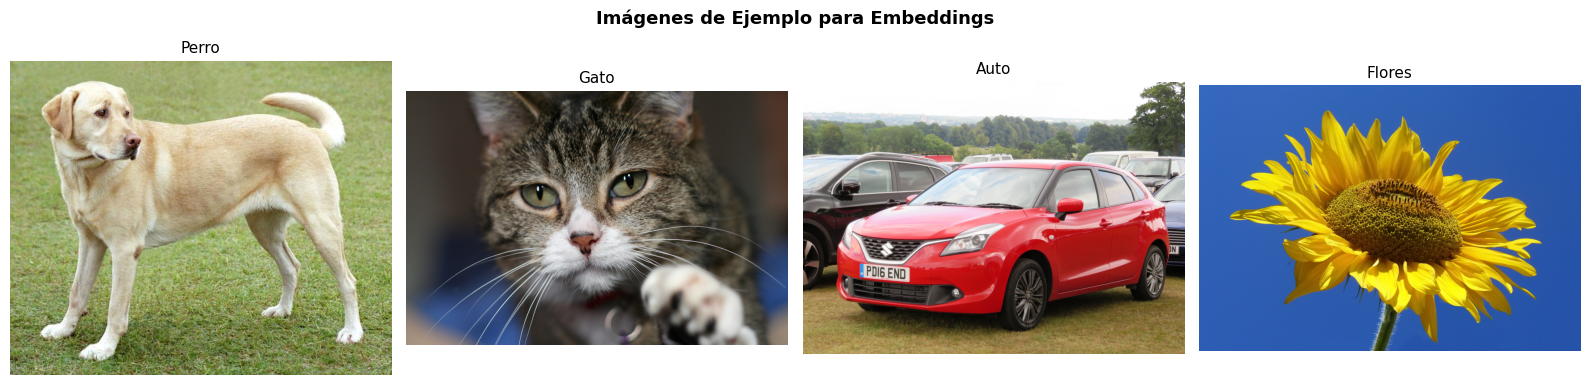

In [ ]:
# ── Visualizar las imágenes de ejemplo ──────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Imágenes de Ejemplo para Embeddings", fontsize=13, fontweight='bold')

for ax, (nombre, img_bytes) in zip(axes, imagenes_bytes.items()):
    img = Image.open(BytesIO(img_bytes))
    ax.imshow(img)
    ax.set_title(nombre.capitalize(), fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# ── Generar embeddings de imágenes ────────────────────────────────────────────
def embed_imagen(img_bytes, mime_type="image/jpeg"):
    """Genera un embedding para una imagen dada como bytes."""
    resultado = client.models.embed_content(
        model=MODEL,
        contents=types.Part.from_bytes(
            data=img_bytes,
            mime_type=mime_type
        )
    )
    return np.array(resultado.embeddings[0].values)

print("Generando embeddings de imágenes...")
embeddings_imgs = {}
for nombre, img_bytes in imagenes_bytes.items():
    embeddings_imgs[nombre] = embed_imagen(img_bytes)
    print(f"  ✓ {nombre}: vector de {len(embeddings_imgs[nombre])} dims")

print("\n✅ Embeddings de imágenes generados.")

Generando embeddings de imágenes...
  ✓ perro: vector de 3072 dims
  ✓ gato: vector de 3072 dims
  ✓ auto: vector de 3072 dims
  ✓ flores: vector de 3072 dims

✅ Embeddings de imágenes generados.


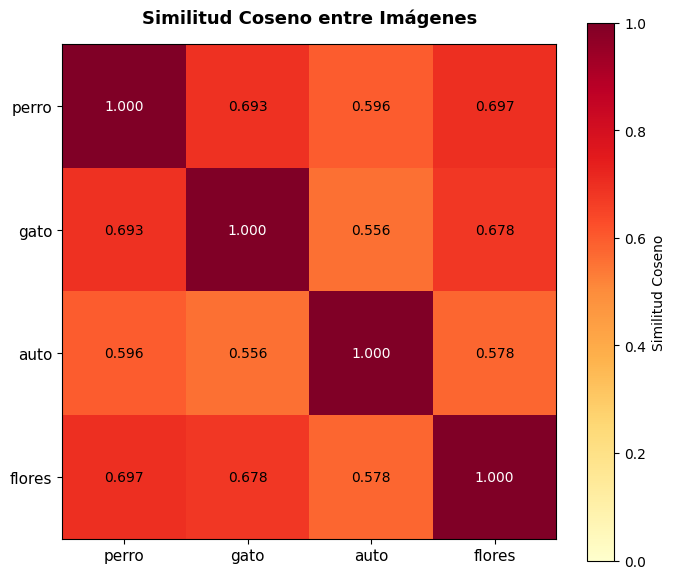

Observación: perro y gato tienen mayor similitud entre sí
(ambos son animales domésticos) que con un auto o flores.


In [ ]:
# ── Matriz de similitud entre imágenes ───────────────────────────────────────
nombres = list(embeddings_imgs.keys())
n = len(nombres)
matriz_sim = np.zeros((n, n))

for i, n1 in enumerate(nombres):
    for j, n2 in enumerate(nombres):
        matriz_sim[i, j] = cosine_sim(embeddings_imgs[n1], embeddings_imgs[n2])

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(matriz_sim, cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(range(n)); ax.set_xticklabels(nombres, fontsize=11)
ax.set_yticks(range(n)); ax.set_yticklabels(nombres, fontsize=11)
ax.set_title("Similitud Coseno entre Imágenes", fontsize=13, fontweight='bold', pad=15)

for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{matriz_sim[i,j]:.3f}", ha='center', va='center', fontsize=10,
                color='white' if matriz_sim[i,j] > 0.7 else 'black')

plt.colorbar(im, ax=ax, label='Similitud Coseno')
plt.tight_layout()
plt.show()

print("Observación: perro y gato tienen mayor similitud entre sí")
print("(ambos son animales domésticos) que con un auto o flores.")

---
## 5. Embeddings Multimodales: Texto + Imagen en un Solo Vector

La característica más poderosa de Gemini Embedding 2: combinar múltiples modalidades en **un único vector agregado**.

In [ ]:
# ── Embedding multimodal (texto + imagen en una sola llamada) ────────────────
def embed_texto_e_imagen(texto, img_bytes, mime_type="image/jpeg"):
    """
    Genera un embedding UNIFICADO que combina texto e imagen.
    El resultado es un solo vector que captura ambas modalidades.
    """
    resultado = client.models.embed_content(
        model=MODEL,
        contents=[
            texto,
            types.Part.from_bytes(data=img_bytes, mime_type=mime_type)
        ]
    )
    return np.array(resultado.embeddings[0].values)

# Ejemplo: imagen de perro con diferentes descripciones
img_perro = imagenes_bytes["perro"]

print("Comparando embeddings multimodales vs. unimodales:\n")

emb_solo_img    = embed_imagen(img_perro)
emb_texto_correcto = embed_texto_e_imagen("Un perro labrador amarillo mirando a la cámara", img_perro)
emb_texto_incorrecto = embed_texto_e_imagen("Un automóvil rojo en la autopista", img_perro)

sim_correcto   = cosine_sim(emb_solo_img, emb_texto_correcto)
sim_incorrecto = cosine_sim(emb_solo_img, emb_texto_incorrecto)

print(f"  Imagen sola  ↔  Imagen + 'perro labrador':   {sim_correcto:.4f} ✅")
print(f"  Imagen sola  ↔  Imagen + 'automóvil rojo':   {sim_incorrecto:.4f} ❌")
print()
print("La descripción correcta produce un vector más cercano al embedding de la imagen sola.")

Comparando embeddings multimodales vs. unimodales:

  Imagen sola  ↔  Imagen + 'perro labrador':   0.3995 ✅
  Imagen sola  ↔  Imagen + 'automóvil rojo':   0.2176 ❌

La descripción correcta produce un vector más cercano al embedding de la imagen sola.


---
## 6. Búsqueda Cross-Modal: Buscar Imágenes con Texto

Como todos los tipos de datos comparten el mismo espacio vectorial, podemos buscar imágenes usando consultas de texto y viceversa.

In [ ]:
# ── Sistema de búsqueda cross-modal ──────────────────────────────────────────
# "Índice" de imágenes con sus embeddings
catalogo = {
    nombre: embed_imagen(img_bytes)
    for nombre, img_bytes in imagenes_bytes.items()
}

def buscar_imagen_con_texto(consulta_texto, top_k=2):
    """Busca imágenes en el catálogo usando una consulta de texto."""
    emb_consulta = get_embedding(f"task: search result | query: {consulta_texto}")

    puntuaciones = {
        nombre: cosine_sim(emb_consulta, emb_img)
        for nombre, emb_img in catalogo.items()
    }

    # Ordenar por similitud
    resultados = sorted(puntuaciones.items(), key=lambda x: x[1], reverse=True)
    return resultados[:top_k]

# Prueba de búsqueda cross-modal
consultas = [
    "mascota peluda y amigable",
    "vehículo de transporte",
    "naturaleza y plantas",
    "animal doméstico felino",
]

print("Búsqueda Cross-Modal: Texto → Imágenes")
print("=" * 55)
for consulta in consultas:
    resultados = buscar_imagen_con_texto(consulta)
    print(f"\n🔍 Consulta: '{consulta}'")
    for i, (nombre, score) in enumerate(resultados, 1):
        barra = "█" * int(score * 30)
        print(f"   #{i} {nombre:10s}  {score:.4f} {barra}")

Búsqueda Cross-Modal: Texto → Imágenes

🔍 Consulta: 'mascota peluda y amigable'
   #1 gato        0.5648 ████████████████
   #2 perro       0.5593 ████████████████

🔍 Consulta: 'vehículo de transporte'
   #1 flores      0.5127 ███████████████
   #2 auto        0.4993 ██████████████

🔍 Consulta: 'naturaleza y plantas'
   #1 flores      0.5933 █████████████████
   #2 perro       0.5428 ████████████████

🔍 Consulta: 'animal doméstico felino'
   #1 gato        0.6166 ██████████████████
   #2 perro       0.5613 ████████████████


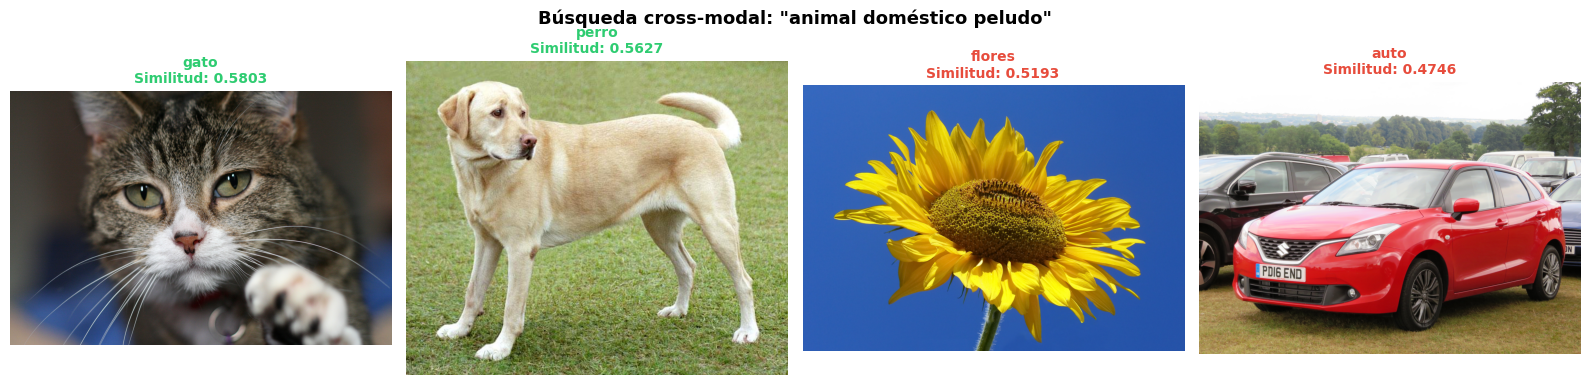

In [ ]:
# ── Visualización: resultado de búsqueda cross-modal ─────────────────────────
consulta_demo = "animal doméstico peludo"
resultados_demo = buscar_imagen_con_texto(consulta_demo, top_k=4)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle(f'Búsqueda cross-modal: "{consulta_demo}"', fontsize=13, fontweight='bold')

for ax, (nombre, score) in zip(axes, resultados_demo):
    img = Image.open(BytesIO(imagenes_bytes[nombre]))
    ax.imshow(img)
    color = '#2ecc71' if score > 0.55 else '#e74c3c'
    ax.set_title(f"{nombre}\nSimilitud: {score:.4f}", fontsize=10, color=color, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

---
## 7. Reducción de Dimensionalidad con MRL

Gemini Embedding 2 usa **Matryoshka Representation Learning (MRL)**: el vector de 3072 dims puede truncarse a dimensiones menores manteniendo la mayor parte de la información semántica.

Esto es útil para:
- Reducir costos de almacenamiento en bases de datos vectoriales
- Disminuir latencia en búsquedas
- Ambientes con restricciones de memoria

In [ ]:
# ── Comparar calidad con diferentes dimensiones ───────────────────────────────
dimensiones = [128, 256, 512, 768, 1536, 3072]

# Pares de frases para evaluar
frase_a = "El modelo de lenguaje procesa texto para generar respuestas"
frase_b = "La IA analiza oraciones para producir contestaciones"
frase_c = "La economía global enfrenta desafíos en los mercados financieros"

print("Efecto de la dimensionalidad en la similitud coseno")
print(f"Frase A: '{frase_a[:50]}...'")
print(f"Frase B (similar): '{frase_b[:50]}...'")
print(f"Frase C (diferente): '{frase_c[:50]}...'")
print()
print(f"{'Dims':>6}  {'Sim A-B':>10}  {'Sim A-C':>10}  {'Diferencia':>12}")
print("-" * 45)

for dims in dimensiones:
    def get_emb_dim(text, d=dims):
        res = client.models.embed_content(
            model=MODEL,
            contents=text,
            config=types.EmbedContentConfig(output_dimensionality=d)
        )
        return np.array(res.embeddings[0].values)

    ea = get_emb_dim(frase_a)
    eb = get_emb_dim(frase_b)
    ec = get_emb_dim(frase_c)

    sim_ab = cosine_sim(ea, eb)
    sim_ac = cosine_sim(ea, ec)
    diferencia = sim_ab - sim_ac

    print(f"{dims:>6}  {sim_ab:>10.4f}  {sim_ac:>10.4f}  {diferencia:>12.4f}")

Efecto de la dimensionalidad en la similitud coseno
Frase A: 'El modelo de lenguaje procesa texto para generar r...'
Frase B (similar): 'La IA analiza oraciones para producir contestacion...'
Frase C (diferente): 'La economía global enfrenta desafíos en los mercad...'

  Dims     Sim A-B     Sim A-C    Diferencia
---------------------------------------------
   128      0.8632      0.6422        0.2210
   256      0.7985      0.5486        0.2498
   512      0.8008      0.5874        0.2134
   768      0.7682      0.5457        0.2225
  1536      0.7643      0.5341        0.2302
  3072      0.7608      0.5338        0.2270


---
## 8. Visualización del Espacio de Embeddings con PCA y t-SNE

Visualicemos cómo los embeddings agrupan conceptos similares en el espacio vectorial.

In [ ]:
# ── Dataset de frases por categorías ─────────────────────────────────────────
dataset = {
    "🐾 Animales": [
        "El perro ladró en el parque",
        "El gato ronroneó sobre la almohada",
        "El pájaro cantó al amanecer",
        "El elefante cruzó el río",
        "La ballena nada en el océano",
    ],
    "💻 Tecnología": [
        "El procesador ejecuta millones de operaciones por segundo",
        "La red neuronal se entrena con gradiente descendente",
        "El algoritmo de búsqueda optimiza el tiempo de respuesta",
        "La base de datos almacena registros de forma eficiente",
        "El modelo de lenguaje genera texto coherente",
    ],
    "🍽️ Gastronomía": [
        "El chef preparó una salsa bechamel cremosa",
        "El postre de chocolate tenía una textura suave",
        "La paella valenciana llevaba mariscos frescos",
        "El pan artesanal se horneó durante 40 minutos",
        "El vino tinto maridó perfectamente con el queso",
    ],
    "⚽ Deportes": [
        "El delantero anotó un gol en el último minuto",
        "El tenista ganó el set con un saque impecable",
        "El maratonista cruzó la meta después de 3 horas",
        "El árbitro cobró un penalti polémico",
        "La selección clasificó al mundial con un empate",
    ],
}

# Generar embeddings para todas las frases
todas_frases = []
todas_etiquetas = []
todos_colores = []
colores_cat = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12"]

print("Generando embeddings por categoría...")
for i, (categoria, frases) in enumerate(dataset.items()):
    for frase in frases:
        emb = get_embedding(frase)
        todas_frases.append(frase)
        todas_etiquetas.append(categoria)
        todos_colores.append(colores_cat[i])
    print(f"  ✓ {categoria}")

matriz_embeddings = np.array([get_embedding(f) for f in todas_frases])
print(f"\n✅ Matriz de embeddings: {matriz_embeddings.shape}")

Generando embeddings por categoría...
  ✓ 🐾 Animales
  ✓ 💻 Tecnología
  ✓ 🍽️ Gastronomía
  ✓ ⚽ Deportes

✅ Matriz de embeddings: (20, 3072)


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/tmp/ipykernel_9207/518792040.py:40: UserWarning: Glyph 128062 (\N{PAW PRINTS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9207/518792040.py:40: UserWarning: Glyph 128187 (\N{PERSONAL COMPUTER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9207/518792040.py:40: UserWarning: Glyph 127869 (\N{FORK AND KNIFE WITH PLATE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9207/518792040.py:40: UserWarning: Glyph 9917 (\N{SOCCER BALL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128062 (\N{PAW PRINTS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.p

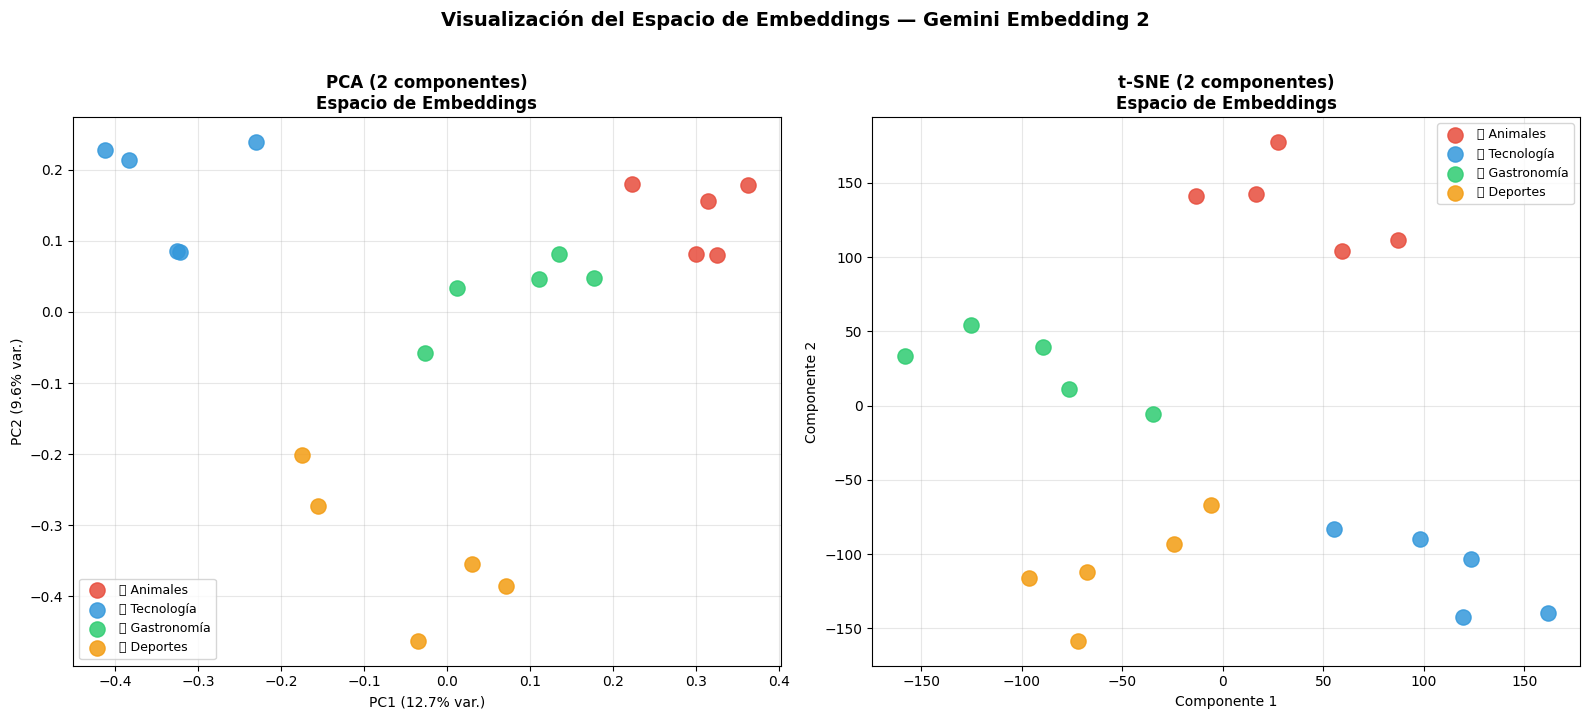

Los puntos del mismo color (misma categoría) deben estar agrupados,
demostrando que los embeddings capturan similaridad semántica.


In [ ]:
# ── Visualización con PCA ─────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
coords_pca = pca.fit_transform(matriz_embeddings)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ─ PCA ─
ax = axes[0]
for i, (categoria, color) in enumerate(zip(dataset.keys(), colores_cat)):
    mask = [e == categoria for e in todas_etiquetas]
    xs = [coords_pca[j, 0] for j, m in enumerate(mask) if m]
    ys = [coords_pca[j, 1] for j, m in enumerate(mask) if m]
    ax.scatter(xs, ys, c=color, s=120, alpha=0.85, label=categoria, zorder=3)

ax.set_title("PCA (2 componentes)\nEspacio de Embeddings", fontsize=12, fontweight='bold')
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var.)", fontsize=10)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var.)", fontsize=10)
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

# ─ t-SNE ─
tsne = TSNE(n_components=2, random_state=42, perplexity=5, n_iter=1000)
coords_tsne = tsne.fit_transform(matriz_embeddings)

ax = axes[1]
for i, (categoria, color) in enumerate(zip(dataset.keys(), colores_cat)):
    mask = [e == categoria for e in todas_etiquetas]
    xs = [coords_tsne[j, 0] for j, m in enumerate(mask) if m]
    ys = [coords_tsne[j, 1] for j, m in enumerate(mask) if m]
    ax.scatter(xs, ys, c=color, s=120, alpha=0.85, label=categoria, zorder=3)

ax.set_title("t-SNE (2 componentes)\nEspacio de Embeddings", fontsize=12, fontweight='bold')
ax.set_xlabel("Componente 1", fontsize=10)
ax.set_ylabel("Componente 2", fontsize=10)
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle("Visualización del Espacio de Embeddings — Gemini Embedding 2",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Los puntos del mismo color (misma categoría) deben estar agrupados,")
print("demostrando que los embeddings capturan similaridad semántica.")

---
## 9. Caso de Uso Completo: Mini-RAG Multimodal

Construyamos un sistema de Retrieval-Augmented Generation (RAG) que combina texto e imágenes.

In [ ]:
# ── Base de datos de documentos multimodales ──────────────────────────────────
# Simulamos un catálogo de productos con nombre, descripción e imagen

catalogo_productos = [
    {
        "id": "P001",
        "nombre": "Labrador Retriever",
        "descripcion": "Raza de perro amigable, ideal para familias. Color dorado, muy activo.",
        "categoria": "Mascotas",
        "imagen_nombre": "perro"
    },
    {
        "id": "P002",
        "nombre": "Gato Doméstico",
        "descripcion": "Felino independiente y elegante. Ideal para apartamentos pequeños.",
        "categoria": "Mascotas",
        "imagen_nombre": "gato"
    },
    {
        "id": "P003",
        "nombre": "Suzuki Baleno",
        "descripcion": "Automóvil eficiente en combustible. Bajo impacto ambiental.",
        "categoria": "Vehículos",
        "imagen_nombre": "auto"
    },
    {
        "id": "P004",
        "nombre": "Girasol Decorativo",
        "descripcion": "Planta ornamental de colores vivos. Perfecta para jardines y decoración.",
        "categoria": "Plantas",
        "imagen_nombre": "flores"
    },
]

# Indexar con embeddings multimodales (texto + imagen)
print("Indexando catálogo con embeddings multimodales...")
indice = []
for producto in catalogo_productos:
    texto = f"{producto['nombre']}. {producto['descripcion']}"
    img_bytes = imagenes_bytes.get(producto['imagen_nombre'])

    if img_bytes:
        # Embedding MULTIMODAL: combina texto + imagen
        emb = embed_texto_e_imagen(texto, img_bytes)
        tipo = "multimodal"
    else:
        # Solo texto si no hay imagen
        emb = get_embedding(texto)
        tipo = "texto"

    indice.append({
        **producto,
        "embedding": emb,
        "tipo_embedding": tipo
    })
    print(f"  ✓ [{tipo:12s}] {producto['nombre']}")

print("\n✅ Catálogo indexado.")

Indexando catálogo con embeddings multimodales...
  ✓ [multimodal  ] Labrador Retriever
  ✓ [multimodal  ] Gato Doméstico
  ✓ [multimodal  ] Suzuki Baleno
  ✓ [multimodal  ] Girasol Decorativo

✅ Catálogo indexado.


In [ ]:
# ── Motor de búsqueda multimodal ──────────────────────────────────────────────
def buscar_catalogo(consulta, top_k=3, usar_imagen_query=None):
    """
    Busca en el catálogo usando texto o texto + imagen.

    Args:
        consulta: texto de búsqueda
        top_k: número de resultados
        usar_imagen_query: bytes de imagen para búsqueda multimodal
    """
    # Generar embedding de la consulta
    if usar_imagen_query is not None:
        emb_query = embed_texto_e_imagen(
            f"task: search result | query: {consulta}",
            usar_imagen_query
        )
        print(f"🔍 Búsqueda multimodal (texto + imagen): '{consulta}'")
    else:
        emb_query = get_embedding(f"task: search result | query: {consulta}")
        print(f"🔍 Búsqueda por texto: '{consulta}'")

    # Calcular similitudes
    resultados = []
    for item in indice:
        score = cosine_sim(emb_query, item['embedding'])
        resultados.append((score, item))

    # Ordenar y retornar top_k
    resultados.sort(key=lambda x: x[0], reverse=True)
    return resultados[:top_k]

# Prueba 1: búsqueda solo texto
print("=" * 60)
resultados = buscar_catalogo("mascota para niños en casa")
for score, item in resultados:
    print(f"  [{score:.4f}] {item['nombre']} ({item['categoria']})")
    print(f"           {item['descripcion'][:60]}...")

print()

# Prueba 2: búsqueda de vehículos
print("=" * 60)
resultados = buscar_catalogo("transporte ecológico")
for score, item in resultados:
    print(f"  [{score:.4f}] {item['nombre']} ({item['categoria']})")

print()

# Prueba 3: búsqueda cross-modal (imagen como query)
print("=" * 60)
resultados = buscar_catalogo("¿Qué es esto?", usar_imagen_query=imagenes_bytes["gato"])
for score, item in resultados:
    print(f"  [{score:.4f}] {item['nombre']} ({item['categoria']})")

🔍 Búsqueda por texto: 'mascota para niños en casa'
  [0.5638] Gato Doméstico (Mascotas)
           Felino independiente y elegante. Ideal para apartamentos peq...
  [0.5306] Labrador Retriever (Mascotas)
           Raza de perro amigable, ideal para familias. Color dorado, m...
  [0.4596] Girasol Decorativo (Plantas)
           Planta ornamental de colores vivos. Perfecta para jardines y...

🔍 Búsqueda por texto: 'transporte ecológico'
  [0.4957] Suzuki Baleno (Vehículos)
  [0.4254] Gato Doméstico (Mascotas)
  [0.4140] Labrador Retriever (Mascotas)

🔍 Búsqueda multimodal (texto + imagen): '¿Qué es esto?'
  [0.4473] Labrador Retriever (Mascotas)
  [0.4456] Girasol Decorativo (Plantas)
  [0.4438] Gato Doméstico (Mascotas)


🔍 Búsqueda por texto: 'animal doméstico amigable'


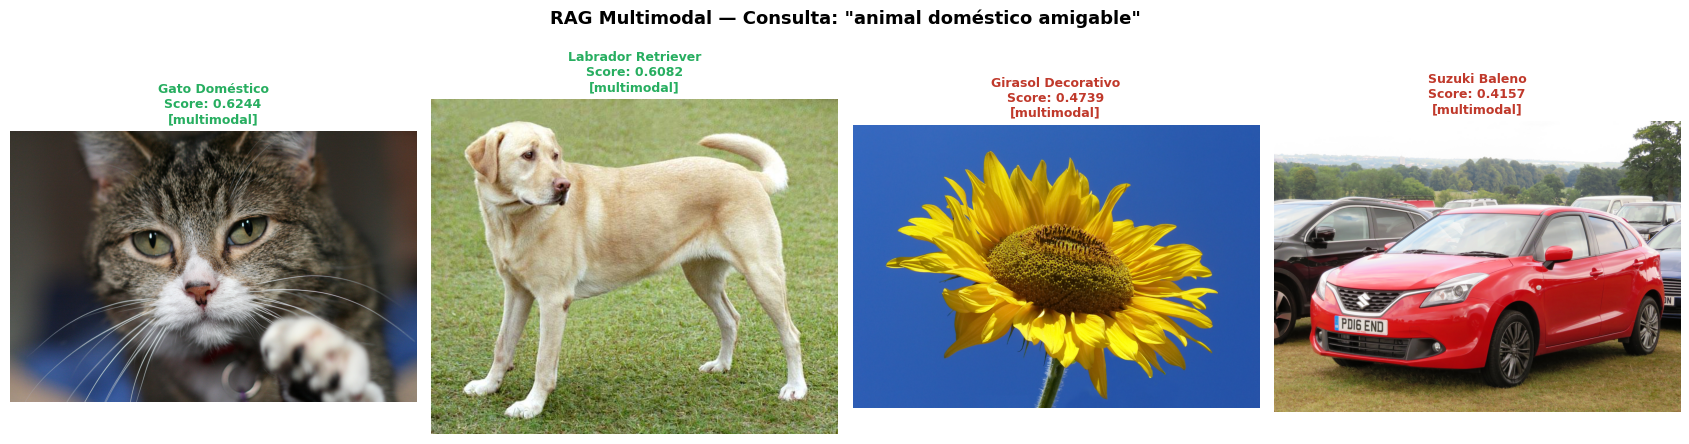

In [ ]:
# ── Visualización final del sistema RAG ──────────────────────────────────────
consulta_final = "animal doméstico amigable"
resultados_final = buscar_catalogo(consulta_final, top_k=4)

fig, axes = plt.subplots(1, 4, figsize=(17, 5))
fig.suptitle(f'RAG Multimodal — Consulta: "{consulta_final}"',
             fontsize=13, fontweight='bold')

for ax, (score, item) in zip(axes, resultados_final):
    img_bytes = imagenes_bytes.get(item["imagen_nombre"])
    if img_bytes:
        img = Image.open(BytesIO(img_bytes))
        ax.imshow(img)
    else:
        ax.text(0.5, 0.5, "Sin imagen", ha='center', va='center', transform=ax.transAxes)

    color = '#27ae60' if score > 0.6 else '#e67e22' if score > 0.5 else '#c0392b'
    ax.set_title(
        f"{item['nombre']}\nScore: {score:.4f}\n[{item['tipo_embedding']}]",
        fontsize=9, color=color, fontweight='bold'
    )
    ax.axis('off')

plt.tight_layout()
plt.show()

---
## 10. Resumen y Mejores Prácticas

### ✅ Qué aprendimos

| Concepto | Descripción |
|---|---|
| **Embedding** | Vector numérico que representa el significado semántico de un dato |
| **Similitud coseno** | Métrica principal para comparar embeddings |
| **Espacio unificado** | Texto, imagen, audio y video en el mismo espacio vectorial |
| **Task prefixes** | Instrucciones que mejoran la calidad para tareas específicas |
| **MRL** | Truncar dimensiones para optimizar almacenamiento sin perder mucha calidad |
| **Cross-modal search** | Buscar imágenes con texto o texto con imágenes |
| **RAG Multimodal** | Recuperación de información combinando múltiples tipos de datos |

### 🚀 Mejores Prácticas

1. **Siempre usa task prefixes** para búsqueda asimétrica (query ≠ documento)
2. **Evalúa con ranking**, no con umbrales fijos de similitud
3. **MRL 768 dims** es un buen balance entre calidad y costo de almacenamiento
4. **Usa Batch API** para indexar grandes volúmenes (50% más barato)
5. **No mezcles** embeddings de `gemini-embedding-001` con `gemini-embedding-2` — son espacios incompatibles
6. Para búsqueda de texto puro, considera también `gemini-embedding-001`

### 📚 Recursos

- [Documentación oficial — Gemini Embeddings](https://ai.google.dev/gemini-api/docs/embeddings)
- [Google AI Studio (obtener API key)](https://aistudio.google.com/apikey)
- [Cookbook de Gemini en GitHub](https://github.com/google-gemini/cookbook)
- [Blog post de lanzamiento — Gemini Embedding 2](https://blog.google/innovation-and-ai/models-and-research/gemini-models/gemini-embedding-2/)